# Examen 

In [1]:
# Your imports HERE !!!!
import numpy as np  #exporta numpy para calculos y arreglos
import pandas as pd #exporta pandas para tablas o dataframes

## 01 - 1 pt
- Dado un array de elementos, escribir una función, que reciba dicho array como parámetro de entrada y devuelva el elemento repetido. Usando plain Python, sin ninguna librería.

In [20]:
array_src = [4, 8, 0, 3, 6, 2, 1, 5, 3, 9, 7]
expected_rep_element = 3
rep_element = repeated_element(array_src) # This calls your function repeated_element
assert(expected_rep_element == rep_element)  # This will fail if the element is not found correctly
print("El elemento repetido es:", rep_element) #Agregado para imprimir resultado

El elemento repetido es: 3


In [18]:
def repeated_element(array):
    vistos = set() #conjunto vacío que guarda elementos repetidos
    
    for elemento in array: #Se recorreo cada elemento
        if elemento in vistos: #Identifica el elemento repetido si lo encuentra en el conjunto de vistos
            return elemento

        vistos.add(elemento) #En el caso en eque no esté en el conjunto , se agrega

## 02 - 1pt
- Genera una matriz con valores aleatorios de 0 a 100 de dimensiones 16x16
- Calcula los siguentes estadísticos en la matriz anterior, por fila (el resultado de cada uno debe ser un array de dimensiones 1x16)
  - Suma de los elementos de cada fila
  - Media de los elementos de cada fila
  - Valores mínimos de cada fila
  - Valores máximos de cada fila

In [23]:
matriz = np.random.randint(0,101 , size = (16,16)) #Segundo dato excluyente , Fila columna

#axis se usa para cálculo fila por fila, es importación de numpy

suma = matriz.sum(axis=1)
resta = matriz.mean(axis=1)
minimo = matriz.min(axis=1)
maximo = matriz.max(axis=1)

print("Suma por fila:", suma)
print("Media por fila:", resta)
print("mínimo por fila:", minimo)
print("máximo por fila:", maximo)

Suma por fila: [ 756  793  726  661  901  653  924  912  779  809  566 1020  869  984
  847  814]
Media por fila: [47.25   49.5625 45.375  41.3125 56.3125 40.8125 57.75   57.     48.6875
 50.5625 35.375  63.75   54.3125 61.5    52.9375 50.875 ]
mínimo por fila: [ 0  9  1  1  0  3  7  6  7  1  1 29 16  0 18  3]
máximo por fila: [ 92  97  95  99  97  96  96  93  94  93  81  87 100 100  98  98]


## 03 - 1pt

- Generar un dataframe de 3x4 dimensiones con valores númericos aleatorios [0,10]
- Darle un índice semántico alfanumérico
- Aplicarle una función lambda que obtenga la diferencia entre el máximo y mínimo de cada fila

In [27]:
data = np.random.randint(0, 11, size = (3,4))
df = pd.DataFrame(data) #Genero el dataframe

df.index = ['data_A', 'data_B', 'data_C'] #Asignar nombres a las filas

diferencia = df.apply(lambda x : x.max() - x.min(), axis=1) #Axis para que se ejecute en fila 
print("DataFrame:\n", df)
print("\nDiferencia entre max y min por fila:\n", diferencia)

DataFrame:
         0   1  2   3
data_A  4   7  9   8
data_B  6   4  3  10
data_C  1  10  8   2

Diferencia entre max y min por fila:
 data_A    5
data_B    7
data_C    9
dtype: int64


## 04 - 1pt
- Crear un array de NumPy de dimensiones 8x5, con números enteros aleatorios en el rango [-100, 100]
- Ejecutar en este orden

  1. Reemplazar los valores de todos aquellos números múltiplos de 5 por 100
  2. Reemplazar los valores de todos aquellos números múltiplos de 3 por Nan
   
  2. Averiguar cuantos elementos tienen Nan por fila
  3. Reemplazar los valores de Nan por 0

In [45]:
array = np.random.randint(-100, 101, size = (8,5)).astype(float)

array[array %5 == 0] = 100 #Se usa el módulo para saber si la división para 5 da 0
array[array %3 == 0] = np.nan #Se usa el módulo para saber si la división para 3 da 0 y se reemplaza por NaN

nan = np.isnan(array).sum(axis=1) #np.isnan usa un booleano y axis ejecuta fila por fila sumando los true

print("\nArray 8x5 es:\n", array)

print("\nCantidad de NaNs por fila \n:", nan)



Array 8x5 es:
 [[ nan -77. 100.  nan 100.]
 [100.  38. 100. 100.  89.]
 [ 31.  92. -64. 100. 100.]
 [-43. -38.  58.  nan -68.]
 [ 98. -98. -62. 100.  26.]
 [100. 100.  nan  nan -26.]
 [ nan -23.  nan   1. 100.]
 [-49. -76.  44.  nan  nan]]

Cantidad de NaNs por fila 
: [2 0 0 1 0 2 2 2]


In [46]:
array[np.isnan(array)] = 0 #reemplaza valores nan por 0

## 05 - 1pt
- Crear una función que reciba una lista de strings y devuelva una serie de pandas, y convierta el primer y último carácter de la palabra de cada elemento de la serie a mayúsculas

In [50]:
languages = ['python', 'php', 'java', 'javascript', 'c++', 'sql']
expected_output = pd.Series(['PythoN', 'PhP', 'JavA', 'JavascripT', 'C++', 'SqL'])
output = first_last_uppercase(languages)  # This calls your function first_last_uppercase
assert(expected_output.equals(output))  # This will fail if the two lists are different

In [51]:
def first_last_uppercase(palabras):
    resultado = [] #lista vacía
    
    for palabra in palabras:
        if len(palabra) > 1: #se verifica que al menos se tenga una letra en la palabra
            nueva_palabra = palabra[0].upper() + palabra[1:-1] + palabra[-1].upper()  
            # Concatenamos: 1ra letra (mayúscula) + medio (intacto) + última letra (mayúscula)
        else:
            nueva_palabra = palabra.upper() # 1 letra = En mayúscula  
        resultado.append(nueva_palabra)
        
    # Convertimos la lista resultante en una Serie de Pandas y la retornamos
    return pd.Series(resultado)

print(output)

0        PythoN
1           PhP
2          JavA
3    JavascripT
4           C++
5           SqL
dtype: object


## 07 - 1pt
- La serie de Fibonacci es una sucesión de números, en la cual cada número es la suma de los dos anteriores. Los dos primeros son siempre 0 y 1.
  - $F_0 = 0$
  - $F_1 = 1$
  - $F_n = F_{n-1} + F_{n-2}$
- Crear un generador infinito de números de Fibonacci.

In [53]:
fibo = [0,1,1,2,3,5,8,13,21,34,55,89,144,233,377,610,987,1597]
g = fibonacci_generator()  # This calls tour function fibonacci_generator
expected_output = [next(g) for n in range(len(fibo))]
assert(fibo == expected_output)  # This will fail if the output is not as expected

In [60]:
def fibonacci_generator():
    a = 0
    b = 1

    #Bucle infinito
    while True: 
        yield a  # "yield" pausa la función y entrega a . Para generadores

        a, b = b, a + b #a es b y se vuelve la suma de ambos

print(expected_output)

[0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597]


## 07 - 4pt
- Crear una lista de meses de Enero a Diciembre (eje X)
- Generar datos aleatorios para el eje Y, hacerlo 3 veces distintas (Y0, Y1 e Y2)
- Representar las 3 secuencias de datos aleatorios en una sola figura usando matplotlib
- Añadir una leyenda para poder identificar cada secuencia
- Nombrar las 3 secuencias de la siguiente manera ("Facebook", "Twitter", "Instagram")
- Añadir un título y nombres a los dos ejes
- Añadir una anotación (texto y flecha) a uno de los gráficos

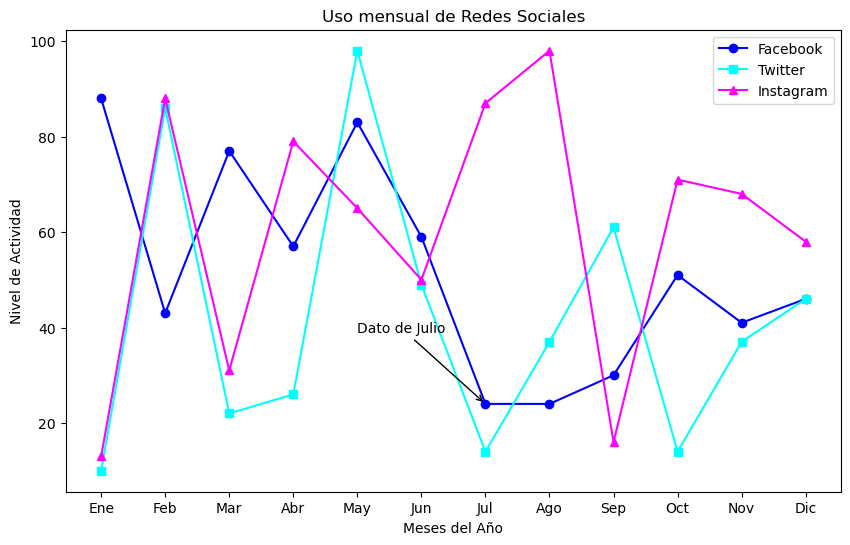

In [65]:
import matplotlib.pyplot as plt

meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# Generar 12 números aleatorios entre 10 y 100 
Y0 = np.random.randint(10, 101, size=12) 
Y1 = np.random.randint(10, 101, size=12) 
Y2 = np.random.randint(10, 101, size=12) 

plt.figure(figsize=(10, 6)) #ajuste de tamaño, fila , columna

# Usar marker para distinción
plt.plot(meses, Y0, label="Facebook", marker='o', color='blue') #circulo 
plt.plot(meses, Y1, label="Twitter", marker='s', color='cyan') #cuadrado
plt.plot(meses, Y2, label="Instagram", marker='^', color='magenta') #triángulo

#Añadir un título y nombres a los dos ejes
plt.title("Uso mensual de Redes Sociales") #título gráfico
plt.xlabel("Meses del Año") #Títulos del eje X
plt.ylabel("Nivel de Actividad") #Títulos del eje X

#Añadir una anotación (texto y flecha) a uno de los gráficos
plt.annotate('Dato de Julio', 
             xy=('Jul', Y0[6]), # La punta de la flecha
             xytext=('May', Y0[6] + 15), 
             arrowprops=dict(facecolor='black', arrowstyle='->')) # Estilo de flecha

# leyenda de secuencia , cuadro que incluye los label
plt.legend()

# Mostrar el gráfico
plt.show()